# Student Performance — Análisis Estadístico

## Educación

Análisis estadístico del rendimiento académico de estudiantes utilizando
Python, Pandas, Matplotlib, Seaborn y SciPy.

## 1. Objetivo

Analizar el rendimiento académico de los estudiantes e identificar
relaciones entre las notas y variables asociadas al desempeño,
como horas de estudio, asignaturas reprobadas, y educación
de los padres.

La variable principal del análisis será `Notas 3 Periodo`, utilizada
como indicador del rendimiento académico final disponible en el dataset.

## 2. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## 3. Carga de datos

In [2]:
df = pd.read_excel("Student_Performance.xlsx")

In [3]:
df.head()

,Colegio,Género,Edad,Zona Vivienda,Tamaño Familia,Situación Convivencia Padres,Educación Madre,Educación Padre,Ocupación Madre,Ocupación Padre,...,Relación Familiar,Tiempo Libre,Salida con Amigos,Consumo Alcohol días laborales,Consumo de Alcohol fin de semana,Estado Salud,Ausencias,Notas 1 Periodo,Notas 2 Periodo,Notas 3 Periodo
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [4]:
df.shape

(649, 33)

## 4. Exploración inicial

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype
---  ------                            --------------  -----
 0   Colegio                           649 non-null    str  
 1   Género                            649 non-null    str  
 2   Edad                              649 non-null    int64
 3   Zona Vivienda                     649 non-null    str  
 4   Tamaño Familia                    649 non-null    str  
 5   Situación Convivencia Padres      649 non-null    str  
 6   Educación Madre                   649 non-null    int64
 7   Educación Padre                   649 non-null    int64
 8   Ocupación Madre                   649 non-null    str  
 9   Ocupación Padre                   649 non-null    str  
 10  Razón para asistir a la escuela   649 non-null    str  
 11  Apoderado                         649 non-null    str  
 12  Tiempo de Traslado                649 non-null 

In [6]:
df.isnull().sum()

Colegio                             0
Género                              0
Edad                                0
Zona Vivienda                       0
Tamaño Familia                      0
Situación Convivencia Padres        0
Educación Madre                     0
Educación Padre                     0
Ocupación Madre                     0
Ocupación Padre                     0
Razón para asistir a la escuela     0
Apoderado                           0
Tiempo de Traslado                  0
Horas de Estudio                    0
Asignaturas Reprobadas              0
Clases Extra                        0
Apoyo Familiar                      0
Pago de clases extras               0
Actividades Extracurriculares       0
Kindergarten                        0
Intención Estudios Superiores       0
Acceso a Internet                   0
Relación Romantica                  0
Relación Familiar                   0
Tiempo Libre                        0
Salida con Amigos                   0
Consumo Alco

### Observaciones iniciales

El dataset contiene 649 estudiantes y 33 variables. La revisión inicial
permite comprobar la estructura de los datos, los tipos de variables y
la presencia de valores faltantes.

No se identifican valores faltantes en las variables del dataset.

## 5. Estadística descriptiva

In [7]:
df.describe()

,Edad,Educación Madre,Educación Padre,Tiempo de Traslado,Horas de Estudio,Asignaturas Reprobadas,Relación Familiar,Tiempo Libre,Salida con Amigos,Consumo Alcohol días laborales,Consumo de Alcohol fin de semana,Estado Salud,Ausencias,Notas 1 Periodo,Notas 2 Periodo,Notas 3 Periodo
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


In [8]:
df[
    [
        "Notas 1 Periodo",
        "Notas 2 Periodo",
        "Notas 3 Periodo"
    ]
].describe()

,Notas 1 Periodo,Notas 2 Periodo,Notas 3 Periodo
count,649.000000,649.000000,649.000000
mean,11.399076,11.570108,11.906009
std,2.745265,2.913639,3.230656
min,0.000000,0.000000,0.000000
25%,10.000000,10.000000,10.000000
50%,11.000000,11.000000,12.000000
75%,13.000000,13.000000,14.000000
max,19.000000,19.000000,19.000000


In [9]:
df["Notas 3 Periodo"].skew()

np.float64(-0.9129093547157225)

### Distribución de N3

La distribución de las N3 presenta una asimetría negativa
(skewness ≈ -0,91). La media es 11,91 y la mediana es 12, lo que indica
una distribución con mayor extensión hacia los valores bajos.

## 6. Distribución de las notas N1, N2 y N3

### Objetivo

Comparar la distribución de las notas de los tres periodos
académicos e identificar diferencias en su concentración y dispersión.

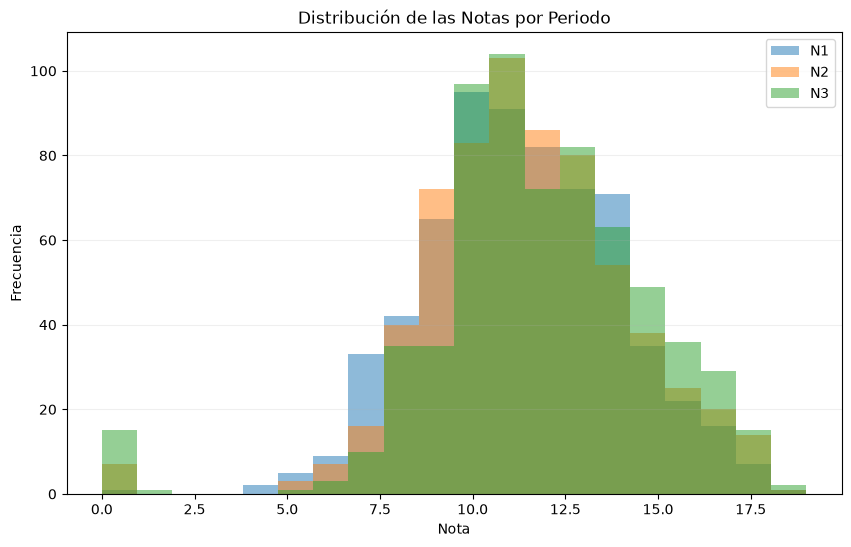

In [10]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["Notas 1 Periodo"],
    bins=20,
    alpha=0.5,
    label="N1"
)

plt.hist(
    df["Notas 2 Periodo"],
    bins=20,
    alpha=0.5,
    label="N2"
)

plt.hist(
    df["Notas 3 Periodo"],
    bins=20,
    alpha=0.5,
    label="N3"
)

plt.xlabel("Nota")
plt.ylabel("Frecuencia")
plt.title("Distribución de las Notas por Periodo")
plt.legend()
plt.grid(axis="y", alpha=0.2)

plt.show()

### Interpretación

Las distribuciones de N1, N2 y N3 presentan concentraciones similares,
principalmente alrededor de las notas medias. La media aumenta
progresivamente desde N1 (11,40) hasta N3 (11,91).

N3 presenta una mayor dispersión que N1 y N2, con una desviación estándar
de 3,23 frente a 2,75 en N1 y 2,91 en N2.

La distribución de N3 presenta además una asimetría negativa
(skewness ≈ -0,91), asociada a una mayor extensión hacia las notas bajas.

## 7. Relación entre las notas N2 y N3

### Objetivo

Analizar la relación entre las notas del segundo y tercer
periodo y evaluar qué tan estrechamente se relacionan ambas variables.

In [11]:
correlacion_g2_g3 = df["Notas 2 Periodo"].corr(
    df["Notas 3 Periodo"]
)

print(f"Correlación G2-G3: {correlacion_g2_g3:.3f}")

Correlación G2-G3: 0.919


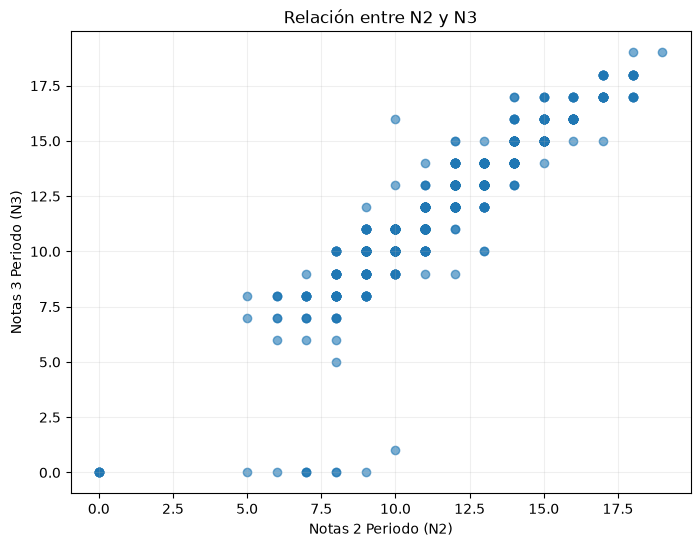

In [12]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["Notas 2 Periodo"],
    df["Notas 3 Periodo"],
    alpha=0.6
)

plt.xlabel("Notas 2 Periodo (N2)")
plt.ylabel("Notas 3 Periodo (N3)")
plt.title("Relación entre N2 y N3")

plt.grid(alpha=0.2)

plt.show()

In [13]:
r = df["Notas 2 Periodo"].corr(
    df["Notas 3 Periodo"]
)

r_squared = r ** 2

print(f"R²: {r_squared:.3f}")

R²: 0.844


### Interpretación

Existe una fuerte relación lineal positiva entre las notas del segundo
y tercer periodo (r = 0,919).

El coeficiente de determinación es R² = 0,844, lo que indica que,
dentro de este análisis lineal, aproximadamente el 84,4% de la
variabilidad observada en N3 se asocia estadísticamente con N2.

El gráfico muestra una concentración de los puntos alrededor de una
tendencia ascendente.

Esta relación no debe interpretarse como una relación causal.

## 8. Horas de estudio y rendimiento académico

### Objetivo

Analizar la relación entre las horas de estudio y las notas obtenidas en el tercer periodo (N3).

In [14]:
correlacion_estudio_g3 = df["Horas de Estudio"].corr(
    df["Notas 3 Periodo"]
)

print(f"Correlación: {correlacion_estudio_g3:.3f}")

Correlación: 0.250


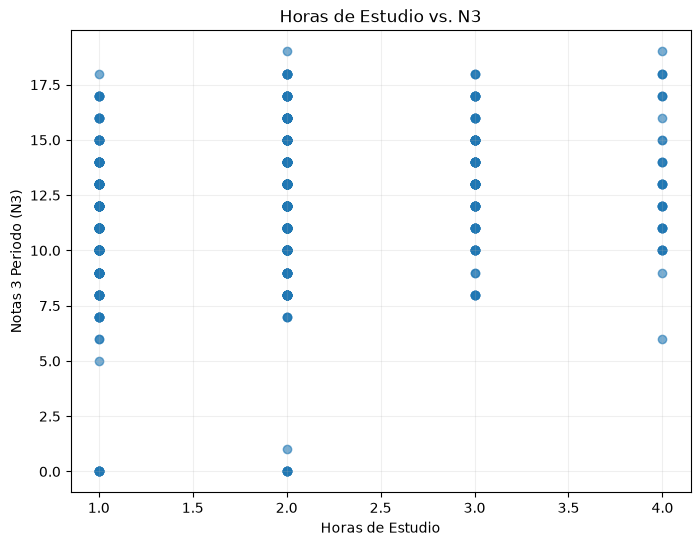

In [15]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["Horas de Estudio"],
    df["Notas 3 Periodo"],
    alpha=0.6
)

plt.xlabel("Horas de Estudio")
plt.ylabel("Notas 3 Periodo (N3)")
plt.title("Horas de Estudio vs. N3")

plt.grid(alpha=0.2)

plt.show()

In [16]:
df.groupby("Horas de Estudio")["Notas 3 Periodo"].agg(
    ["count", "mean", "median", "std", "min", "max"]
).round(2)

,count,mean,median,std,min,max
Horas de Estudio,,,,,,
1,212,10.84,11.0,3.22,0,18
2,305,12.09,12.0,3.24,0,19
3,97,13.23,13.0,2.50,8,18
4,35,13.06,13.0,3.04,6,19


### Interpretación
Nota: Se agruparon las horas de estudio en 4 grupos. Grupo 1 (<2 horas), Grupo 2 (2-5 horas), Grupo 3 (6-10 horas) y Grupo 4 (>10 horas).

La correlación entre las horas de estudio y N3 es positiva y de magnitud
moderada-baja (r = 0,250).

Al agrupar a los estudiantes por horas de estudio, se observa que la
media de N3 aumenta desde 10,84 en el grupo que estudia menos de 2 horas hasta
13,23 en el grupo que estudia entre 6-10 horas.

El grupo 4 presenta una media de 13,06, ligeramente inferior a pesar de estudiar más de 10 horas.

Los resultados muestran una asociación positiva entre horas de estudio
y rendimiento académico en esta muestra, pero no permiten establecer
que las horas de estudio sean la causa de las diferencias observadas
en las notas.

## 9. Asignaturas reprobadas y rendimiento académico

### Objetivo

Analizar la relación entre las asignaturas reprobadas y el rendimiento
académico final, utilizando la calificación del tercer periodo (N3).

In [17]:
correlacion_reprobadas_g3 = df["Asignaturas Reprobadas"].corr(
    df["Notas 3 Periodo"]
)

print(f"Correlación: {correlacion_reprobadas_g3:.3f}")

Correlación: -0.393


In [18]:
df.groupby("Asignaturas Reprobadas")["Notas 3 Periodo"].agg(
    ["count", "mean", "median", "std", "min", "max"]
).round(2)

,count,mean,median,std,min,max
Asignaturas Reprobadas,,,,,,
0,549,12.51,12.0,2.83,0,19
1,70,8.64,10.0,3.44,0,16
2,16,8.81,9.5,3.21,0,15
3,14,8.07,8.5,2.79,0,11


In [19]:
df["Tiene Reprobadas"] = df["Asignaturas Reprobadas"] > 0

In [20]:
df["Tiene Reprobadas"].value_counts()

Tiene Reprobadas
False    549
True     100
Name: count, dtype: int64

In [21]:
df.groupby("Tiene Reprobadas")["Notas 3 Periodo"].agg(
    ["count", "mean", "median", "std", "min", "max"]
).round(2)

,count,mean,median,std,min,max
Tiene Reprobadas,,,,,,
False,549,12.51,12.0,2.83,0,19
True,100,8.59,10.0,3.30,0,16


In [22]:
sin_reprobadas = df.loc[
    df["Tiene Reprobadas"] == False,
    "Notas 3 Periodo"
]

con_reprobadas = df.loc[
    df["Tiene Reprobadas"] == True,
    "Notas 3 Periodo"
]

t_stat, p_value = stats.ttest_ind(
    sin_reprobadas,
    con_reprobadas,
    equal_var=False
)

print(f"Estadístico t: {t_stat:.3f}")
print(f"p-value: {p_value:.3e}")

Estadístico t: 11.155
p-value: 1.473e-20


In [23]:
cohen_d = (
    sin_reprobadas.mean() - con_reprobadas.mean()
) / np.sqrt(
    (
        sin_reprobadas.var() +
        con_reprobadas.var()
    ) / 2
)

print(f"Cohen's d: {cohen_d:.3f}")

Cohen's d: 1.275


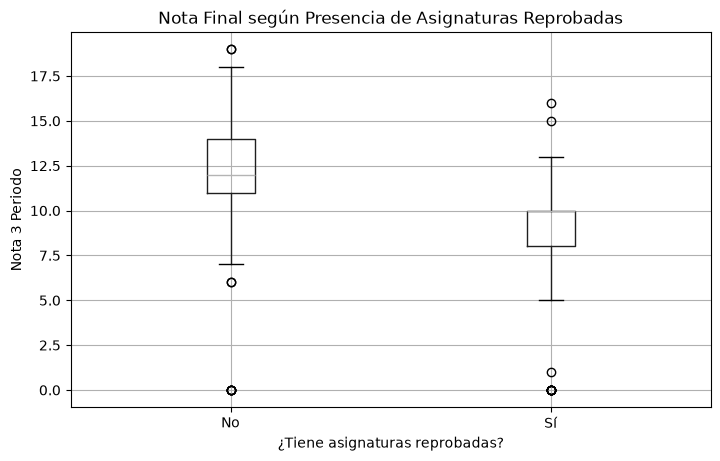

In [24]:
df.boxplot(
    column="Notas 3 Periodo",
    by="Tiene Reprobadas",
    figsize=(8, 5)
)

plt.title("Nota Final según Presencia de Asignaturas Reprobadas")
plt.suptitle("")
plt.xlabel("¿Tiene asignaturas reprobadas?")
plt.ylabel("Nota 3 Periodo")
plt.xticks([1, 2], ["No", "Sí"])
plt.show()

### Interpretación

Se observa una relación negativa entre el número de asignaturas
reprobadas y N3 (r = -0,393).

Los estudiantes sin asignaturas reprobadas presentan una media de N3
de 12,51, mientras que aquellos con al menos una asignatura reprobada
presentan una media de 8,59.

La prueba t muestra una diferencia estadísticamente significativa entre
ambos grupos (t = 11,155; p < 0,001).

El tamaño del efecto de Cohen (d ≈ 1,28) indica una diferencia
estandarizada considerable entre los grupos.

Estos resultados describen una asociación y una diferencia entre grupos
en esta muestra; no permiten establecer que las reprobaciones sean la
causa de las diferencias observadas en N3.

## 10. Educación de los padres y rendimiento académico

### Objetivo

Analizar la relación entre el nivel educativo de la madre y del padre
y el rendimiento académico final de los estudiantes, medido mediante N3.

In [25]:
educacion_madre_g3 = df.groupby("Educación Madre")["Notas 3 Periodo"].agg(
    ["count", "mean", "median"]
).round(2)

educacion_madre_g3

,count,mean,median
Educación Madre,,,
0,6,11.67,11.0
1,143,10.80,11.0
2,186,11.66,12.0
3,139,11.92,12.0
4,175,13.07,13.0


In [26]:
educacion_padre_g3 = df.groupby("Educación Padre")["Notas 3 Periodo"].agg(
    ["count", "mean", "median"]
).round(2)

educacion_padre_g3

,count,mean,median
Educación Padre,,,
0,7,12.14,11.0
1,174,10.94,11.0
2,209,11.78,12.0
3,131,12.38,12.0
4,128,12.92,13.0


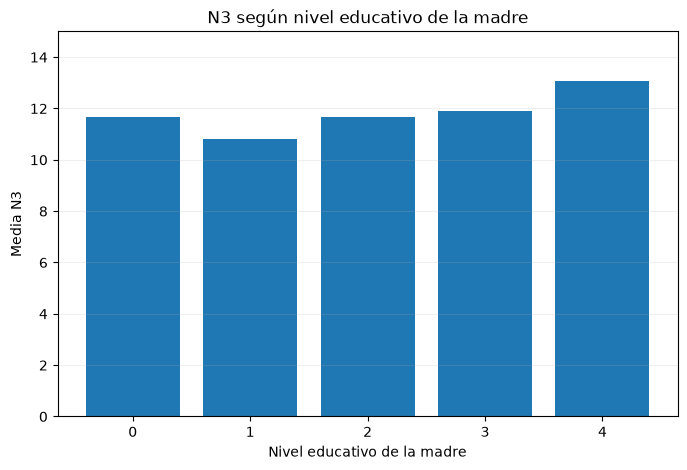

In [27]:
media_madre = df.groupby("Educación Madre")["Notas 3 Periodo"].mean()

plt.figure(figsize=(8, 5))

plt.bar(
    media_madre.index,
    media_madre.values
)

plt.xlabel("Nivel educativo de la madre")
plt.ylabel("Media N3")
plt.title("N3 según nivel educativo de la madre")

plt.ylim(0, 15)
plt.grid(axis="y", alpha=0.2)

plt.show()

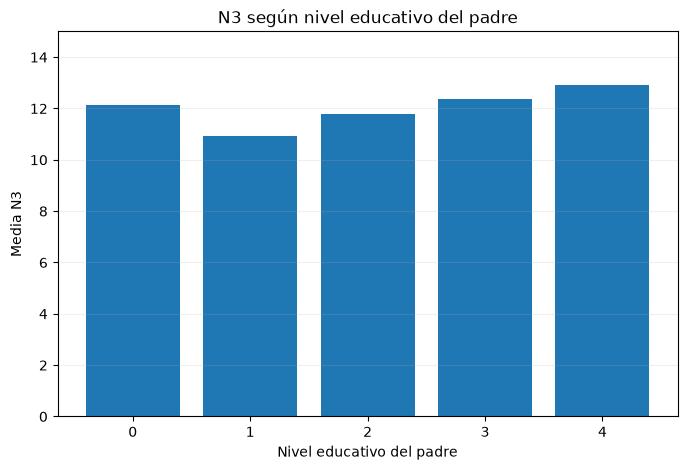

In [28]:
media_padre = df.groupby("Educación Padre")["Notas 3 Periodo"].mean()

plt.figure(figsize=(8, 5))

plt.bar(
    media_padre.index,
    media_padre.values
)

plt.xlabel("Nivel educativo del padre")
plt.ylabel("Media N3")
plt.title("N3 según nivel educativo del padre")

plt.ylim(0, 15)
plt.grid(axis="y", alpha=0.2)

plt.show()

In [29]:
corr_madre = df["Educación Madre"].corr(
    df["Notas 3 Periodo"]
)

corr_padre = df["Educación Padre"].corr(
    df["Notas 3 Periodo"]
)

print(f"Educación Madre vs N3: {corr_madre:.3f}")
print(f"Educación Padre vs N3: {corr_padre:.3f}")

Educación Madre vs N3: 0.240
Educación Padre vs N3: 0.212


### Interpretación

Se observa una asociación positiva entre el nivel educativo de los
padres y N3.

La correlación entre Educación Madre y N3 es 0,240, mientras que entre
Educación Padre y N3 es 0,212.

Al comparar las medias por nivel educativo, los niveles más altos
presentan, en general, mayores medias de N3. Para la madre, la media
aumenta hasta 13,07 en el nivel educativo 4 (educación superior). Para el padre, alcanza
12,92 en el nivel 4 (educación superior).

Los grupos correspondientes al nivel educativo 0 (sin educación) tienen muy pocas
observaciones (6 para la madre y 7 para el padre), por lo que sus
medias deben interpretarse con cautela.

Estos resultados muestran una asociación en la muestra analizada, pero
no permiten establecer una relación causal entre educación de los
padres y rendimiento académico.

## 11. Matriz de correlaciones

### Objetivo

Analizar las relaciones lineales entre las principales variables
numéricas del dataset y las calificaciones de los tres periodos.

In [30]:
variables_corr = [
    "Edad",
    "Educación Madre",
    "Educación Padre",
    "Tiempo de Traslado",
    "Horas de Estudio",
    "Asignaturas Reprobadas",
    "Relación Familiar",
    "Tiempo Libre",
    "Salida con Amigos",
    "Consumo Alcohol días laborales",
    "Consumo de Alcohol fin de semana",
    "Estado Salud",
    "Ausencias",
    "Notas 1 Periodo",
    "Notas 2 Periodo",
    "Notas 3 Periodo"
]

matriz_corr = df[variables_corr].corr()

matriz_corr.round(3)

,Edad,Educación Madre,Educación Padre,Tiempo de Traslado,Horas de Estudio,Asignaturas Reprobadas,Relación Familiar,Tiempo Libre,Salida con Amigos,Consumo Alcohol días laborales,Consumo de Alcohol fin de semana,Estado Salud,Ausencias,Notas 1 Periodo,Notas 2 Periodo,Notas 3 Periodo
Edad,1.000,-0.108,-0.121,0.034,-0.008,0.320,-0.021,-0.005,0.113,0.135,0.086,-0.009,0.150,-0.174,-0.107,-0.107
Educación Madre,-0.108,1.000,0.647,-0.265,0.097,-0.172,0.024,-0.020,0.010,-0.007,-0.020,0.005,-0.009,0.260,0.264,0.240
Educación Padre,-0.121,0.647,1.000,-0.208,0.050,-0.166,0.020,0.007,0.028,0.000,0.038,0.045,0.030,0.218,0.225,0.212
Tiempo de Traslado,0.034,-0.265,-0.208,1.000,-0.063,0.098,-0.010,0.001,0.057,0.093,0.057,-0.048,-0.008,-0.154,-0.154,-0.127
Horas de Estudio,-0.008,0.097,0.050,-0.063,1.000,-0.147,-0.004,-0.069,-0.075,-0.138,-0.215,-0.056,-0.118,0.261,0.240,0.250
Asignaturas Reprobadas,0.320,-0.172,-0.166,0.098,-0.147,1.000,-0.063,0.109,0.045,0.106,0.082,0.036,0.123,-0.384,-0.386,-0.393
Relación Familiar,-0.021,0.024,0.020,-0.010,-0.004,-0.063,1.000,0.129,0.090,-0.076,-0.094,0.110,-0.090,0.049,0.090,0.063
Tiempo Libre,-0.005,-0.020,0.007,0.001,-0.069,0.109,0.129,1.000,0.346,0.110,0.120,0.085,-0.019,-0.094,-0.107,-0.123
Salida con Amigos,0.113,0.010,0.028,0.057,-0.075,0.045,0.090,0.346,1.000,0.245,0.389,-0.016,0.085,-0.074,-0.079,-0.088
Consumo Alcohol días laborales,0.135,-0.007,0.000,0.093,-0.138,0.106,-0.076,0.110,0.245,1.000,0.617,0.059,0.173,-0.195,-0.189,-0.205


In [ ]:
!pip install seaborn

In [32]:
import seaborn as sns

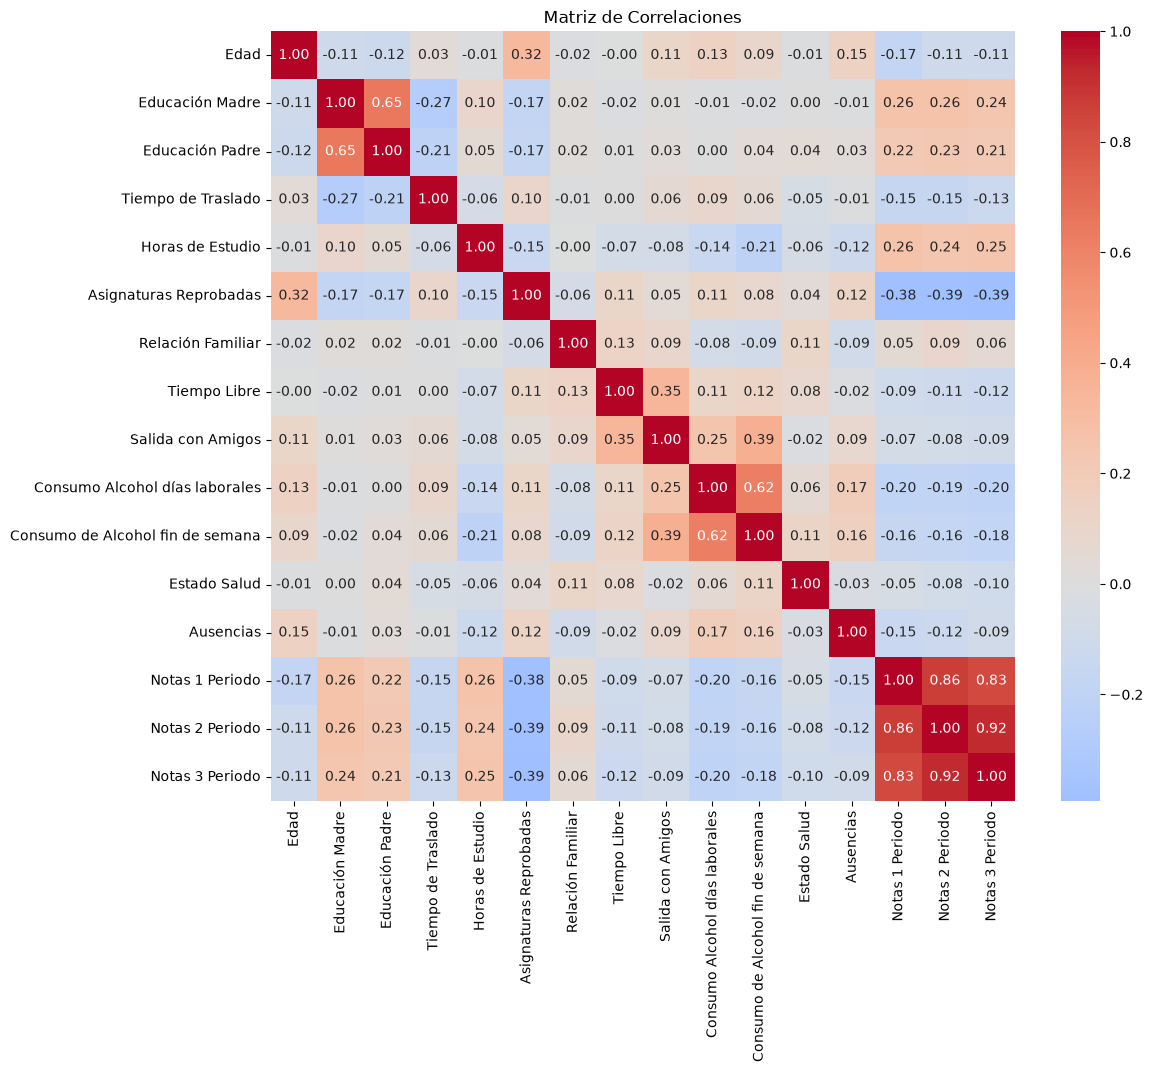

In [33]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    matriz_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de Correlaciones")
plt.show()

### Interpretación

La matriz muestra que las relaciones más fuertes con N3 corresponden
a las notas de los periodos anteriores. N2 presenta una
correlación de 0,919 con N3, mientras que N1 presenta una correlación
de 0,826.

Entre las variables asociadas al comportamiento y contexto del
estudiante, las horas de estudio presentan una correlación positiva
con N3 (0,250), mientras que las asignaturas reprobadas presentan una
correlación negativa (-0,393).

La educación de la madre (0,240) y del padre (0,212) también presentan
correlaciones positivas con N3, aunque de menor magnitud.

Las correlaciones representan asociaciones lineales observadas en la
muestra y no deben interpretarse como relaciones causales.

In [34]:
total_estudiantes = df.shape[0]
promedio_N3 = df["Notas 3 Periodo"].mean()

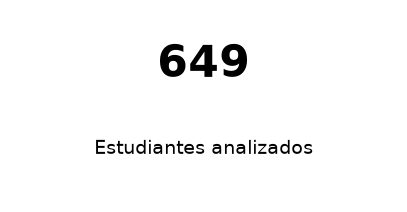

In [35]:
fig, ax = plt.subplots(figsize=(5, 2.5))

ax.text(
    0.5, 0.65,
    f"{total_estudiantes}",
    fontsize=32,
    fontweight="bold",
    ha="center"
)

ax.text(
    0.5, 0.25,
    "Estudiantes analizados",
    fontsize=14,
    ha="center"
)

ax.axis("off")

plt.show()

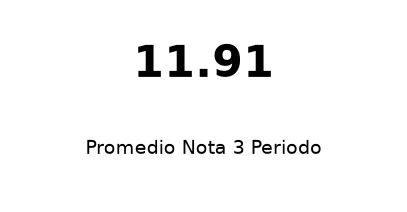

In [36]:
fig, ax = plt.subplots(figsize=(5, 2.5))

ax.text(
    0.5, 0.65,
    f"{promedio_N3:.2f}",
    fontsize=32,
    fontweight="bold",
    ha="center"
)

ax.text(
    0.5, 0.25,
    "Promedio Nota 3 Periodo",
    fontsize=14,
    ha="center"
)

ax.axis("off")

plt.show()

In [37]:
estudiantes_con_reprobadas = (df["Asignaturas Reprobadas"] > 0).sum()
porcentaje_reprobadas = (
    estudiantes_con_reprobadas / total_estudiantes
) * 100

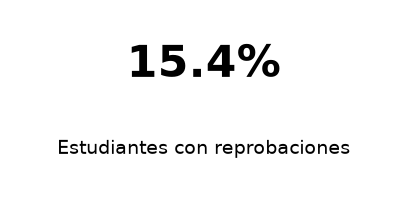

In [38]:
fig, ax = plt.subplots(figsize=(5, 2.5))

ax.text(
    0.5, 0.65,
    f"{porcentaje_reprobadas:.1f}%",
    fontsize=32,
    fontweight="bold",
    ha="center"
)

ax.text(
    0.5, 0.25,
    "Estudiantes con reprobaciones",
    fontsize=14,
    ha="center"
)

ax.axis("off")

plt.show()

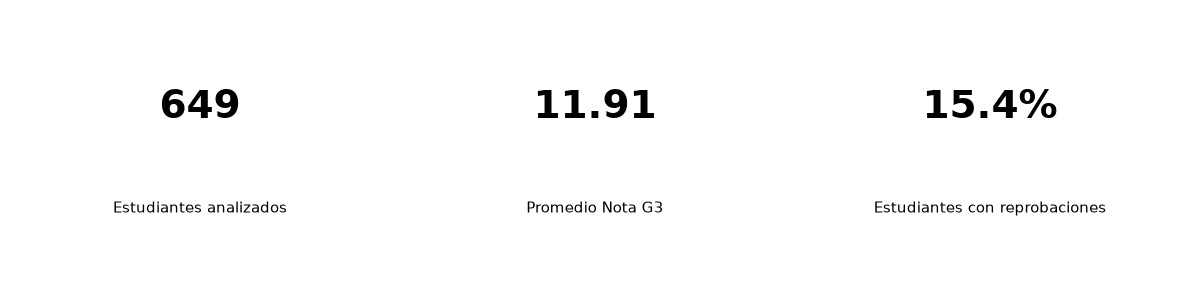

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

kpis = [
    (f"{total_estudiantes}", "Estudiantes analizados"),
    (f"{promedio_N3:.2f}", "Promedio Nota G3"),
    (f"{porcentaje_reprobadas:.1f}%", "Estudiantes con reprobaciones")
]

for ax, (valor, titulo) in zip(axes, kpis):
    ax.text(
        0.5, 0.6,
        valor,
        fontsize=28,
        fontweight="bold",
        ha="center"
    )
    
    ax.text(
        0.5, 0.25,
        titulo,
        fontsize=11,
        ha="center"
    )
    
    ax.axis("off")

plt.tight_layout()
plt.show()

# 12. Hallazgos principales 

### 1. Rendimiento académico

El promedio de N3 fue de 11,91 puntos. Las medias de las notas
aumentaron ligeramente entre los tres periodos:

- N1: 11,40
- N2: 11,57
- N3: 11,91

N3 presentó una desviación estándar de 3,23 y una asimetría negativa
de aproximadamente -0,91.

### 2. Relación entre las notas

N2 presentó una fuerte correlación positiva con N3 (r = 0,919), con un
R² de aproximadamente 0,844.

Esto indica una asociación lineal fuerte entre las notas del
segundo y tercer periodo. La correlación no implica causalidad.

### 3. Horas de estudio

Las horas de estudio presentaron una correlación positiva con N3
(r = 0,250).

La media de N3 fue de 10,84 para quienes estudiaban menos de 2 horas, 12,09 para
quienes estudian entre 2-5 horas, 13,23 para 6-10 horas y 13,06 para más de 10 horas.

Los grupos 3 (6-10 horas) y 4 (más de 10 horas) tienen tamaños muestrales menores que los
grupos 1 (menos de 2 horas) y 2 (2-5 horas), por lo que estas diferencias deben interpretarse
considerando el tamaño de cada grupo.

### 4. Asignaturas reprobadas

Las asignaturas reprobadas presentaron una correlación negativa con N3
(r = -0,393).

Los estudiantes sin asignaturas reprobadas tuvieron una media de N3 de
12,51, mientras que aquellos con al menos una asignatura reprobada
tuvieron una media de 8,59.

La diferencia entre ambos grupos fue estadísticamente significativa
(t = 11,155; p < 0,001), con un tamaño del efecto de Cohen de
aproximadamente 1,28.

Estos resultados muestran una asociación y una diferencia entre grupos,
pero no permiten establecer causalidad.

### 5. Educación de los padres

La educación de la madre presentó una correlación de 0,240 con N3,
mientras que la educación del padre presentó una correlación de 0,212.

En general, los niveles educativos más altos presentaron mayores medias
de N3 en la muestra analizada.

Los grupos con nivel educativo 0 (sin educación) tienen muy pocas observaciones, por lo
que sus medias deben interpretarse con cautela.

# 13. Conclusión

El análisis de 649 estudiantes permitió identificar diferentes
variables asociadas al rendimiento académico del tercer periodo.

Las calificaciones de periodos anteriores mostraron las asociaciones
más fuertes con N3, especialmente N2. También se observaron
asociaciones entre N3 y las horas de estudio, la educación de los
padres y las asignaturas reprobadas.

La diferencia de rendimiento entre estudiantes con y sin asignaturas
reprobadas fue uno de los principales resultados del análisis,
presentando tanto una diferencia de medias estadísticamente
significativa como un tamaño del efecto considerable.

Los resultados describen patrones y asociaciones presentes en la
muestra analizada. No permiten establecer relaciones causales entre las
variables.